In [3]:
import polars as pl

In [4]:
df = pl.read_parquet("final_patient_data.parquet")

In [5]:
df.head(2)

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag,Cardiopathie ischémique,Fibrillation atriale,Insuffisance cardiaque chronique,Pacemaker,Pontage aorto-coronarien,Insuffisance rénale chronique,Antécédent d'AVC,Cirrhose,Cancer actif,Immunodépression,Dyslipidémie,Diabète,beta_blocker,ACEI,ARB,anti_aldosterone,furosemide,gender,birth_date,death_date,age_at_admission,comorbidity_score,hfrs_score,OMT_component_score,death_flag
str,i64,str,datetime[μs],datetime[μs],i64,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,str,date,date,i32,f64,f64,i8,i32
"""P001""",1002,"""angers""",2018-07-04 11:15:00,2018-07-12 10:00:00,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,"""F""",1933-04-12,2018-09-21,85,0.0,0.0,2,1
"""P002""",2002,"""brest""",2019-01-18 13:20:00,2019-01-25 11:00:00,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,"""M""",1934-11-03,null,84,0.0,0.0,0,0


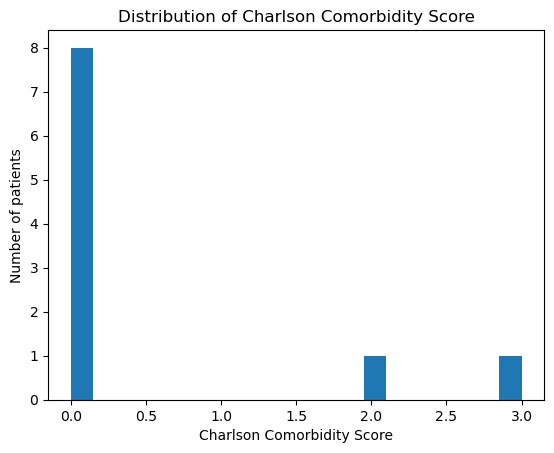

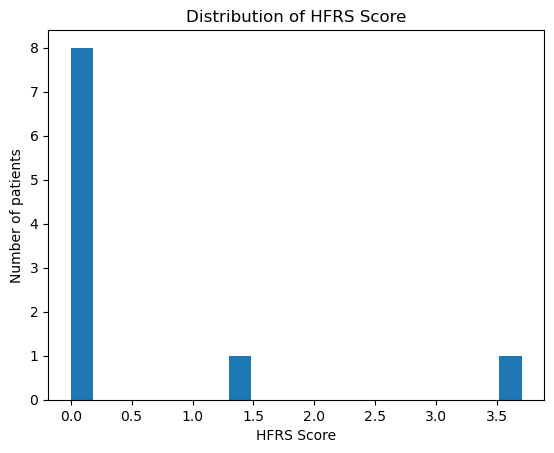

In [6]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["comorbidity_score"].to_numpy(), bins=20)
plt.xlabel("Charlson Comorbidity Score")
plt.ylabel("Number of patients")
plt.title("Distribution of Charlson Comorbidity Score")
plt.show()

plt.figure()
plt.hist(df["hfrs_score"].to_numpy(), bins=20)
plt.xlabel("HFRS Score")
plt.ylabel("Number of patients")
plt.title("Distribution of HFRS Score")
plt.show()

Total number of patients: 10
Number of patients with at least one comorbidity: 5
Percentage: 50.0 %


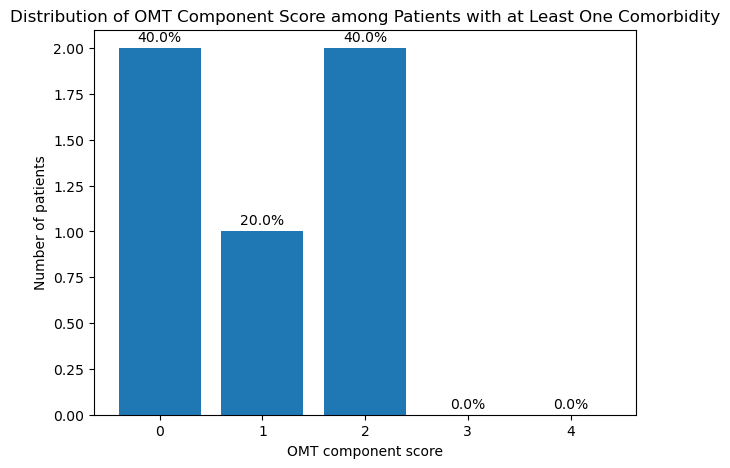

In [9]:
import matplotlib.pyplot as plt
import polars as pl

# List of comorbidity columns
disease_cols = [
    "Cardiopathie ischémique",
    "Fibrillation atriale",
    "Insuffisance cardiaque chronique",
    "Pacemaker",
    "Pontage aorto-coronarien",
    "Antécédent d'AVC"
]

# Keep only patients with at least one recorded comorbidity
# Since disease columns are binary indicators:
# 1 = disease present
# 0 = disease absent
# The horizontal sum gives the number of comorbidities for each patient.
df_with_any_comorbidity = df.filter(
    pl.sum_horizontal([
        pl.col(col) for col in disease_cols
    ]) >= 1
)

# Check the number of patients in the full cohort and in the subpopulation
n_total = df.height
n_subpop = df_with_any_comorbidity.height

print("Total number of patients:", n_total)
print("Number of patients with at least one comorbidity:", n_subpop)
print("Percentage:", round(n_subpop / n_total * 100, 2), "%")

# Define the possible range of OMT component score
# Here we assume the score can vary from 0 to 4.
score_range = pl.DataFrame({
    "OMT_component_score": [0, 1, 2, 3, 4]
})

# Count the number of patients for each OMT component score
# The join with score_range ensures that scores with zero patients are still displayed.
omt_counts = (
    df_with_any_comorbidity
    .group_by("OMT_component_score")
    .len()
    .join(score_range, on="OMT_component_score", how="right")
    .with_columns(pl.col("len").fill_null(0))
    .sort("OMT_component_score")
)

# Convert Polars columns to NumPy arrays for plotting
x = omt_counts["OMT_component_score"].to_numpy()
y = omt_counts["len"].to_numpy()

# Total number of patients in the subpopulation
total = y.sum()

# Plot the distribution of OMT component score
plt.figure(figsize=(7, 5))
plt.bar(x, y)

# Add percentage labels above each bar
for xi, yi in zip(x, y):
    percent = yi / total * 100
    
    plt.text(
        xi,
        yi + max(y) * 0.01,
        f"{percent:.1f}%",
        ha="center",
        va="bottom"
    )

# Use only integer values on the x-axis because OMT score is discrete
plt.xticks([0, 1, 2, 3, 4])

plt.xlabel("OMT component score")
plt.ylabel("Number of patients")
plt.title("Distribution of OMT Component Score among Patients with at Least One Comorbidity")

plt.show()